In [1]:
import pyccl as ccl
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from cosmo_numba.B_modes.schneider2022 import get_pure_EB_modes

In [3]:
from pure_EB_sc import get_pure_EB_modes as get_pure_EB_modes_sc

In [4]:
import matplotlib as mpl

mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['lines.markersize'] = 6

mpl.rcParams['font.size'] = 13

mpl.rcParams['xtick.minor.size'] = 5
mpl.rcParams['ytick.minor.size'] = 5
mpl.rcParams['xtick.major.size'] = 7
mpl.rcParams['ytick.major.size'] = 7


mpl.rcParams['xtick.minor.width'] = 1
mpl.rcParams['ytick.minor.width'] = 1
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['ytick.major.width'] = 1

color = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [5]:
SAVE_FIGS = False

## Cosmo model

In [6]:
def get_model(
    theta,
    z,
    nz,
    Omega_c,
    h,
    Omega_b,
    sig8,
    ns,
    B_amp,
    b_ia,
    l_min=None,
    l_max=None,
    ell=None,
):

    theta_deg = theta/60

    cosmo = ccl.Cosmology(
        Omega_c=Omega_c,
        Omega_b=Omega_b,
        h=h,
        n_s=ns,
        sigma8=sig8,

        transfer_function='boltzmann_camb',
        matter_power_spectrum='camb',
        extra_parameters={
            "camb": {
                "halofit_version": 'mead2016',
                "HMCode_A_baryon": B_amp,
                "kmax": 21,
                # We do this to avoid warnings in CAMB with (kmax < 5 or
                # 'kmax < 20 and z > 4') (set internally in ccl)
                # default: kmax=10
            }
        }
    )
    ccl.gsl_params.LENSING_KERNEL_SPLINE_INTEGRATION = True

    lens = ccl.WeakLensingTracer(
        cosmo,
        dndz=(z, nz),
        ia_bias=(z, np.ones_like(z)*b_ia),
        use_A_ia=True,
    )

    if ell is None:
        if l_min is None and l_max is None:
            l_min = 1
            l_max = 100_000
        l_bin = (l_max - l_min) + 1
        ell = np.logspace(np.log10(l_min), np.log10(l_max), l_bin)
    cl = ccl.angular_cl(cosmo, lens, lens, ell)

    xip_fit = ccl.correlation(
        cosmo,
        ell=ell,
        C_ell=cl,
        theta=theta_deg,
        type='GG+',
        method='fftlog',
    )
    xim_fit = ccl.correlation(
        cosmo,
        ell=ell,
        C_ell=cl,
        theta=theta_deg,
        type='GG-',
        method='fftlog'
    )

    return xip_fit, xim_fit, ell, cl

In [7]:
def smail_nz(z, z0, alpha, beta):
    return (z / z0) ** beta * np.exp(-(z / z0) ** alpha)

## Set parameters

In [8]:
# Thin bins
tmin_int = 0.5
tmax_int = 800
bin_size_int = 0.02
nbins_int = 1_000
print("nbins int:", nbins_int)

tmin = 0.5
tmax = 250
bin_size = 0.3
nbins = int((np.log(tmax) - np.log(tmin))/bin_size)
print("nbins:", nbins)

nbins int: 1000
nbins: 20


In [9]:
# Planck cosmo 2018 | TT,TE,EE+lowE+lensing+BAO
h = 0.6766
Om = 0.3111
Ov = 0.6889
sig8 = 0.8102
ns = 0.9665
Ob_h2 = 0.02242
Ob = Ob_h2/h**2
Oc_h2 = 0.11933
Oc = Oc_h2/h**2
b_ia = 0.5
B_amp = 3.13

area = 14_300
shape_noise = 0.26
n_eff = 27

alpha_nz = 0.68
beta_nz = 2.
z0_nz = 0.13
z = np.linspace(0, 4, 256)
nz = smail_nz(z, z0_nz, alpha_nz, beta_nz)

## Get pure B-modes

In [10]:
theta_ = np.logspace(np.log10(tmin), np.log10(tmax), nbins+1)
theta = np.mean([theta_[:-1], theta_[1:]], axis=0)
theta_int_ = np.logspace(np.log10(tmin_int), np.log10(tmax_int), nbins_int+1)
theta_int = np.mean([theta_int_[:-1], theta_int_[1:]], axis=0)

In [11]:
xip_model_int, xim_model_int, _, _ = get_model(
    theta_int,
    z,
    nz,
    Oc,
    h,
    Ob,
    sig8,
    ns,
    B_amp,
    b_ia,
)

In [12]:
xip_model, xim_model, _, _ = get_model(
    theta,
    z,
    nz,
    Oc,
    h,
    Ob,
    sig8,
    ns,
    B_amp,
    b_ia,
)

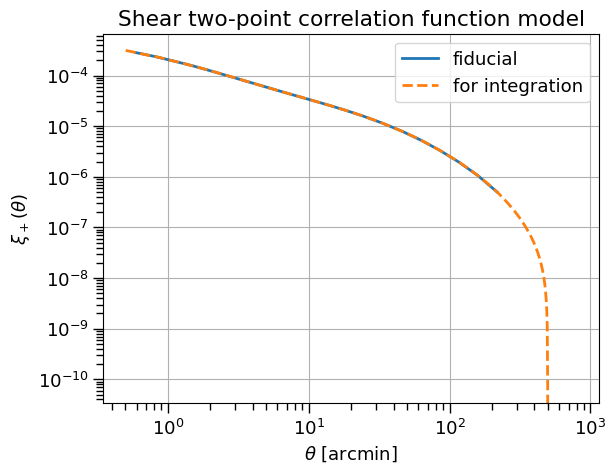

In [13]:
plt.plot(theta, xip_model, label="fiducial")
plt.plot(theta_int, xip_model_int, "--", label="for integration")
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$\theta$ [arcmin]")
plt.ylabel(r"$\xi_+(\theta)$")
plt.legend()
plt.title("Shear two-point correlation function model")
plt.grid()
plt.show()

In [14]:
xip_E_model, xim_E_model, xip_B_model, xim_B_model, xip_amb_model, xim_amb_model = get_pure_EB_modes(
    theta, xip_model, xim_model, theta_int, xip_model_int, xim_model_int, np.min(theta), np.max(theta), parallel=True, pad_xim=True,
    interp_order=5,
)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


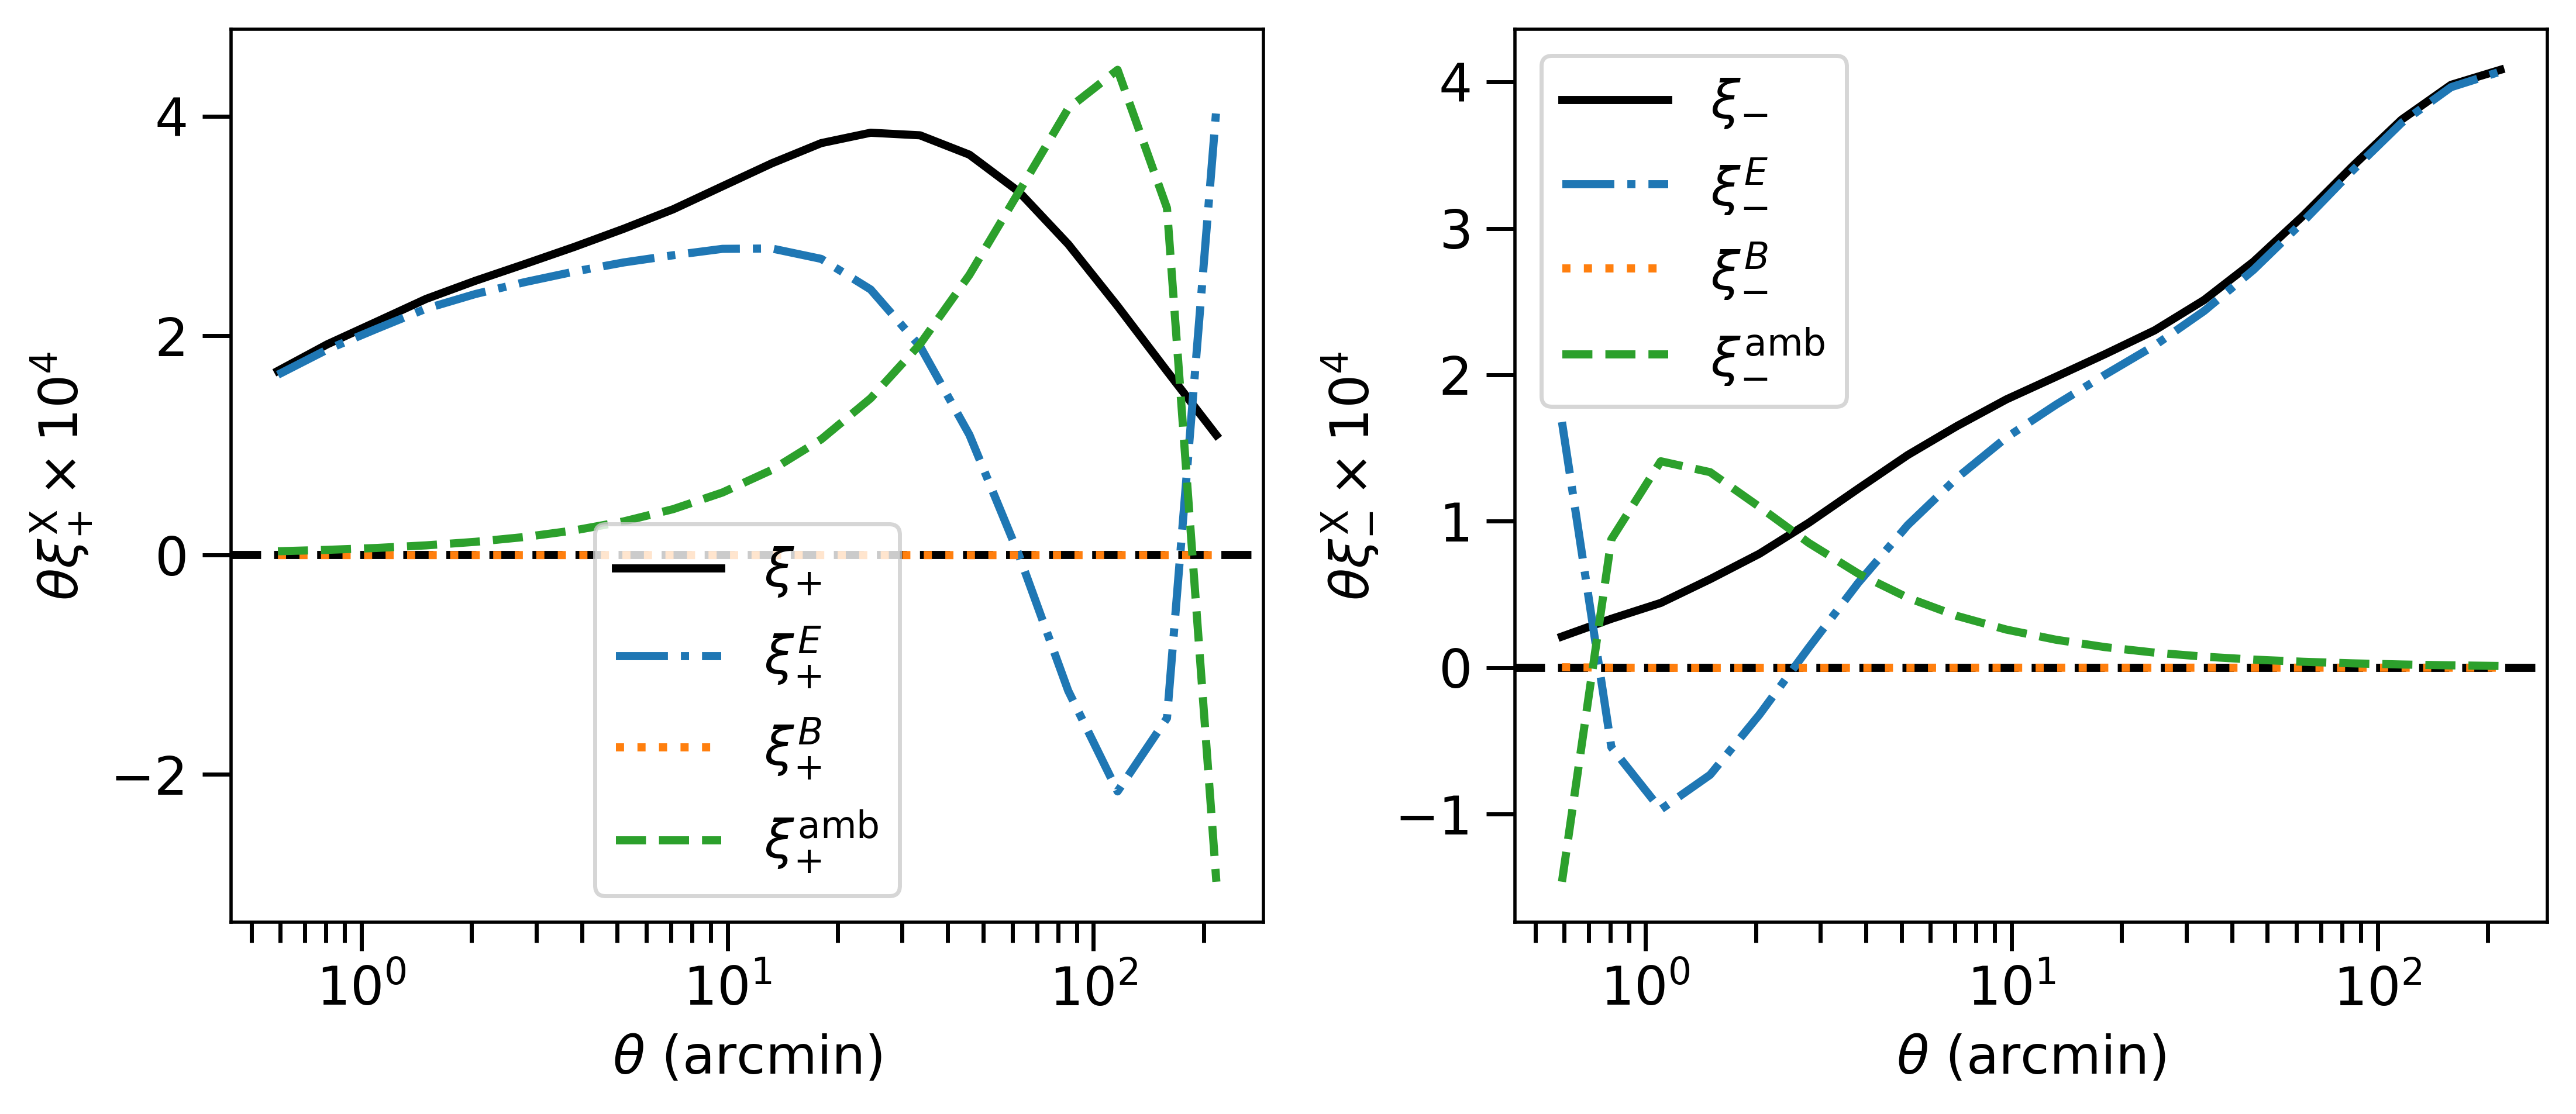

In [15]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(9, 4), dpi=500)
axs[0].plot(theta, theta*xip_model/1e-4, color="k", label=r"$\xi_{+}$")
axs[0].plot(theta, theta*xip_E_model/1e-4, '-.', color=color[0], label=r"$\xi_{+}^{E}$")
axs[0].plot(theta, theta*xip_B_model/1e-4, ':', color=color[1], label=r"$\xi_{+}^{B}$")
axs[0].plot(theta, theta*xip_amb_model/1e-4, '--', color=color[2], label=r"$\xi_{+}^{\mathrm{amb}}$")
axs[0].axhline(0, ls='--', color='k', zorder=0)
axs[0].set_xscale('log')
axs[0].set_xlabel(r"$\theta$ (arcmin)")
axs[0].set_ylabel(r"$\theta\xi^{\rm{X}}_{+}\times10^{4}$")
axs[0].legend()

axs[1].plot(theta, theta*xim_model/1e-4, color="k", label=r"$\xi_{-}$")
axs[1].plot(theta, theta*xim_E_model/1e-4, '-.', color=color[0], label=r"$\xi_{-}^{E}$")
axs[1].plot(theta, theta*xim_B_model/1e-4, ':', color=color[1], label=r"$\xi_{-}^{B}$")
axs[1].plot(theta, theta*xim_amb_model/1e-4, '--', color=color[2], label=r"$\xi_{-}^{\mathrm{amb}}$")
axs[1].axhline(0, ls='--', color='k', zorder=0)
axs[1].set_xscale('log')
axs[1].set_xlabel(r"$\theta$ (arcmin)")
axs[1].set_ylabel(r"$\theta\xi^{\rm{X}}_{-}\times10^{4}$")
axs[1].legend()
plt.tight_layout()
if SAVE_FIGS:
    plt.savefig("../paper/pure_EB.png")